In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import geokit as gk
from geokit.core.get_test_data import get_test_data

In [2]:
# Repository data cache 
data_cache_folder = pathlib.Path().cwd().parents[1].joinpath("geokit", "data")

# Define a region-centered CRS (Aachen)
aachen_centered_srs = gk.srs.centeredLAEA(6.083, 50.775)

# Load RegionMask from example shapefile
aachen_rm = gk.RegionMask.load(
    get_test_data(file_name="aachenShapefile.shp", data_cache_folder=data_cache_folder),
    pixelRes=20,
    srs=aachen_centered_srs,
)

Memory usage during calc: 356.5 MB


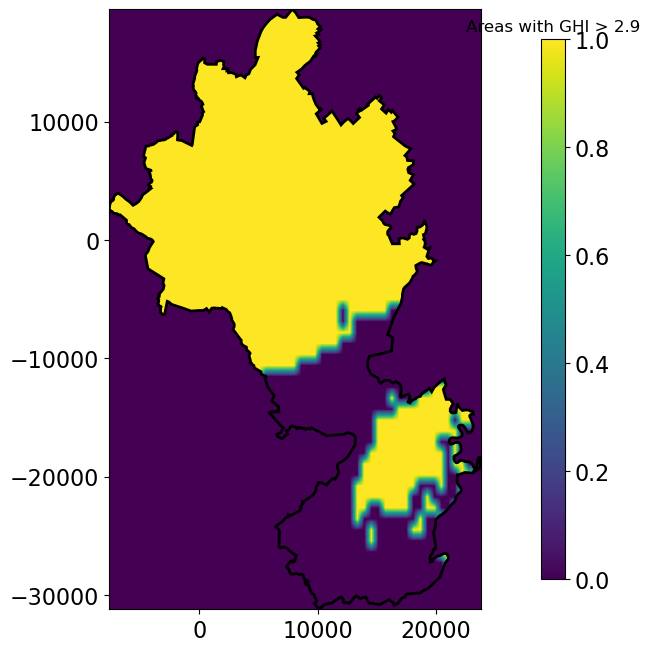

In [5]:
src = get_test_data("gsa-ghi-like.tif", data_cache_folder=data_cache_folder)

mask_thr = aachen_rm.indicateValues(
    source=src,
    value=(2.9, None),
    multiProcess=False,
)
aachen_rm.drawImage(mask_thr, figsize=(6, 6))
plt.title("Areas with GHI > 2.9")
plt.show()


Memory usage during calc: 324.80859375 MB


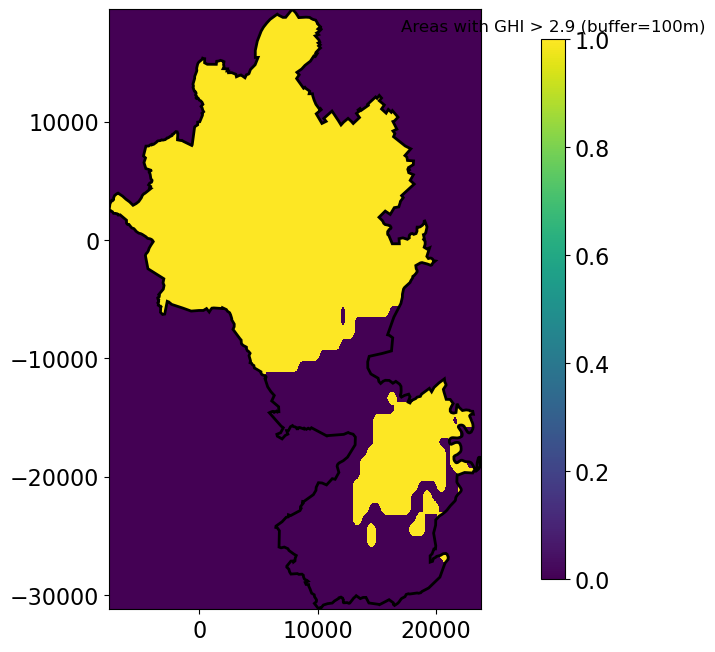

In [6]:
mask_buf = aachen_rm.indicateValues(
    source=src,
    value=(2.9, None),
    buffer=100,
    multiProcess=False,
)

aachen_rm.drawImage(mask_buf, figsize=(6, 6))
plt.title("Areas with GHI > 2.9 (buffer=100m)")
plt.show()